# Simulating Cyclic Voltammetry with Butler–Volmer Kinetics and Unequal Diffusion Coefficients using `solve_ivp`

In cyclic voltammetry (CV), the electrode potential is swept linearly forward and backward. For an **oxidation reaction** under the standard **IUPAC convention**:
$$\mathrm{Red} \underset{k_{\text{red}}}{\overset{k_{\text{ox}}}{\rightleftharpoons}} \mathrm{Ox} + e^-$$
the potential begins at a reducing potential ($E_{\text{start}} = -0.3\text{ V}$ vs. $E^{0'}$), sweeps anodically (in the positive direction) to a positive vertex ($E_{\text{vertex}} = +0.3\text{ V}$), and then reverses back to the initial potential:
$$E(t) = \begin{cases}
E_{\text{start}} + v t, & 0 \le t \le t_{\text{switch}} \\
E_{\text{vertex}} - v (t - t_{\text{switch}}), & t_{\text{switch}} < t \le 2 t_{\text{switch}}
\end{cases}$$
Under IUPAC conventions:
- **Forward sweep (Oxidation)**: The reduced species $\mathrm{Red}$ is oxidized to $\mathrm{Ox}$ ($\mathrm{Red} \to \mathrm{Ox} + e^-$), producing an **anodic peak** at **positive potentials** ($E_{pa} > E^{0'}$) with **positive current** ($I > 0$).
- **Reverse sweep (Reduction)**: The generated species $\mathrm{Ox}$ at the surface is reduced back to $\mathrm{Red}$ ($\mathrm{Ox} + e^- \to \mathrm{Red}$), producing a **cathodic peak** at **negative potentials** ($E_{pc} < E^{0'}$) with **negative current** ($I < 0$).
- **Unequal diffusion coefficients**: In real solutions, the reduced and oxidized forms often carry different charges and solvation shells, leading to unequal diffusion coefficients ($D_{\text{Red}} \neq D_{\text{Ox}}$).

In this tutorial, you will learn how to:
1. Formulate 1D diffusion PDEs with Butler–Volmer oxidation kinetics using the **Method of Lines (MOL)**.
2. Discretize the interfacial flux coupling using a second-order **ghost-node** approach, eliminating algebraic loops and enabling direct solution with `scipy.integrate.solve_ivp`.
3. Simulate and visualize spatio-temporal concentration profiles $c_{\text{Red}}(x, t)$ and $c_{\text{Ox}}(x, t)$ alongside the cyclic voltammogram.
4. Observe the asymmetry in peak currents ($|I_{pc} / I_{pa}| \neq 1$) caused by $D_{\text{Red}} \neq D_{\text{Ox}}$.
5. Sweep scan rates ($v$) and standard rate constants ($k_0$) with high temporal resolution to capture peak shapes cleanly.
6. Benchmark the simulations against the **Nicholson method**, using the dimensionless parameter $\psi$ (generalized for $D_{\text{Red}} \neq D_{\text{Ox}}$) to quantitatively establish the kinetic regimes.

## 1. Physical Model & Second-Order Boundary Discretization

### Governing Equations
Under planar semi-infinite 1D diffusion ($x \in [0, L]$), the transport of species $\mathrm{Red}$ and $\mathrm{Ox}$ is governed by Fick's second law:
$$\frac{\partial c_{\text{Red}}}{\partial t} = D_{\text{Red}} \frac{\partial^2 c_{\text{Red}}}{\partial x^2}, \qquad \frac{\partial c_{\text{Ox}}}{\partial t} = D_{\text{Ox}} \frac{\partial^2 c_{\text{Ox}}}{\partial x^2}$$
with bulk initial conditions $c_{\text{Red}}(x, 0) = c^*_{\text{bulk}}$ and $c_{\text{Ox}}(x, 0) = 0$.

### Butler–Volmer Boundary Condition ($x = 0$)
The potential-dependent heterogeneous oxidation and reduction rate constants are:
$$k_{\text{ox}}(t) = k_0 \exp\left[ (1 - \alpha) \frac{F}{RT} (E(t) - E^{0'}) \right], \qquad k_{\text{red}}(t) = k_0 \exp\left[ -\alpha \frac{F}{RT} (E(t) - E^{0'}) \right]$$
where $k_0$ is the standard heterogeneous rate constant ($\text{cm/s}$) and $\alpha$ is the transfer coefficient (typically $0.5$).

At the electrode surface ($x = 0$), mass conservation without interfacial accumulation requires that the diffusion fluxes equal the net oxidation reaction rate:
$$D_{\text{Red}} \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} = - D_{\text{Ox}} \left.\frac{\partial c_{\text{Ox}}}{\partial x}\right|_{x=0} = k_{\text{ox}}(t) c_{\text{Red}}(0, t) - k_{\text{red}}(t) c_{\text{Ox}}(0, t) \equiv J_{\text{BV}}(t)$$
Under the IUPAC sign convention, the Faradaic current for oxidation is positive:
$$I(t) = F A J_{\text{BV}}(t) = \left.F A D_{\text{Red}} \frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0}$$

### Second-Order Ghost-Node Discretization
On a uniform spatial grid with step size $\Delta x$, we approximate the surface gradient using a fictitious ghost node at $x_{-1} = -\Delta x$:
$$\left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} \approx \frac{c_{\text{Red}, 1} - c_{\text{Red}, -1}}{2 \Delta x} \implies c_{\text{Red}, -1} = c_{\text{Red}, 1} - \frac{2 \Delta x}{D_{\text{Red}}} J_{\text{BV}}(t)$$
Substituting $c_{\text{Red}, -1}$ into the central-difference second spatial derivative at the electrode node $i = 0$:
$$\frac{d c_{\text{Red}, 0}}{d t} = D_{\text{Red}} \frac{c_{\text{Red}, 1} - 2 c_{\text{Red}, 0} + c_{\text{Red}, -1}}{\Delta x^2} = \frac{2 D_{\text{Red}} (c_{\text{Red}, 1} - c_{\text{Red}, 0})}{\Delta x^2} - \frac{2}{\Delta x} J_{\text{BV}}(t)$$
Similarly for the oxidized species $\mathrm{Ox}$:
$$\frac{d c_{\text{Ox}, 0}}{d t} = \frac{2 D_{\text{Ox}} (c_{\text{Ox}, 1} - c_{\text{Ox}, 0})}{\Delta x^2} + \frac{2}{\Delta x} J_{\text{BV}}(t)$$
This eliminates the ghost point algebraically, preserves second-order spatial accuracy $\mathcal{O}(\Delta x^2)$, avoids solving nonlinear equations at each time step, and yields an explicit ODE system $\frac{d \mathbf{y}}{dt} = \mathbf{f}(t, \mathbf{y})$ directly solvable by `scipy.integrate.solve_ivp`.

In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# Physical and electrochemical constants
F = 96485.3  # Faraday constant (C/mol)
R = 8.3145  # Gas constant (J/(mol*K))
T = 298.15  # Temperature (K)
f = F / (R * T)  # Normalized potential factor (~38.92 V^-1)
n = 1  # Number of electrons transferred
A = 0.07  # Electrode geometric area (cm²)
c_bulk = 1e-6  # Bulk concentration of Red (mol/cm³, equivalent to 1.0 mM)
E0 = 0.0  # Formal potential (V)

# Potential limits: sweep from reducing potential to oxidizing potential
E_start = -0.3  # Initial potential (V)
E_vertex = 0.3  # Switching potential (V)

# Unequal diffusion coefficients
D_Red = 1.0e-5  # Diffusion coefficient of reactant Red (cm²/s)
D_Ox = 5.0e-6  # Diffusion coefficient of product Ox (cm²/s)
gamma = np.sqrt(D_Red / D_Ox)  # Asymmetry factor (~1.414)
print(
    f"Diffusion coefficient ratio D_Red / D_Ox = {D_Red / D_Ox:.2f} (gamma = {gamma:.3f})"
)

Diffusion coefficient ratio D_Red / D_Ox = 2.00 (gamma = 1.414)


## 2. Minimal Simulation Helper Function

To keep the tutorial concise, readable, and reusable, we encapsulate the Method of Lines formulation into a single helper function `simulate_cv_bv(v, k0, ...)`.

Key implementation details:
- **Forward & Reverse Waveform**: Potential starts at $E_{\text{start}} = -0.3\text{ V}$ and sweeps positive with slope $+v$ to $E_{\text{vertex}} = +0.3\text{ V}$, then sweeps negative with slope $-v$ back to $-0.3\text{ V}$.
- **Adaptive Domain Sizing**: The domain length $L$ is set to $6 \sqrt{\max(D_{\text{Red}}, D_{\text{Ox}}) \cdot t_{\text{end}}}$, ensuring zero concentration perturbation reaches the outer boundary $x = L$ (semi-infinite condition).
- **Stiff BDF Solver with Step Control (`max_step`)**: The spatial diffusion discretization yields a stiff ODE system. Furthermore, the triangular potential sweep has a slope discontinuity at $t_{\text{switch}}$, and rapid Butler–Volmer rate changes can cause high-order polynomial interpolants to produce numerical ringing or kinks if the solver takes excessively large time steps. Setting `max_step = min(0.01, t_switch / 300.0)` and $n_{\text{eval}} = 1001$ ensures the solver takes small, well-distributed time steps ($\Delta t \le 10\text{ ms}$), providing smooth, high-resolution peaks across all rate constants.
- **Robust Current Calculation**: By Fick's first law, Faradaic current is $I(t) = F A D_{\text{Red}} \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0}$. We evaluate this using a second-order forward difference:
$$\left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} \approx \frac{-3 c_{\text{Red}, 0} + 4 c_{\text{Red}, 1} - c_{\text{Red}, 2}}{2 \Delta x}$$
This maintains high precision across all kinetic regimes without catastrophic cancellation errors when $k_0$ is large.

In [2]:
def simulate_cv_bv(
    v: float,
    k0: float,
    alpha: float = 0.5,
    D_Red: float = 1.0e-5,
    D_Ox: float = 5.0e-6,
    N: int = 101,
    n_eval: int = 1001,
    max_step: float | None = None,
) -> dict:
    # Simulate cyclic voltammetry for an oxidation reaction using solve_ivp
    t_switch = (E_vertex - E_start) / v
    t_end = 2.0 * t_switch

    # Set maximum internal time step to ensure high resolution at peak regions and turning point
    if max_step is None:
        max_step = min(0.01, t_switch / 300.0)

    # Domain length sized to 6x diffusion length of the faster-diffusing species
    L = 6.0 * np.sqrt(max(D_Red, D_Ox) * t_end)
    x = np.linspace(0.0, L, N)
    dx = x[1] - x[0]
    inv_dx2 = 1.0 / (dx**2)

    def rhs(t: float, y: np.ndarray) -> np.ndarray:
        c_R, c_O = y[:N], y[N:]
        # Anodic forward scan (+v), cathodic reverse scan (-v)
        E = E_start + v * t if t <= t_switch else E_vertex - v * (t - t_switch)
        eta = E - E0
        k_ox = k0 * np.exp((1.0 - alpha) * f * eta)
        k_red = k0 * np.exp(-alpha * f * eta)
        J_bv = k_ox * c_R[0] - k_red * c_O[0]  # Net oxidation flux

        dy = np.empty_like(y)
        # Interior points (central differences)
        dy[:N] = D_Red * np.r_[0.0, c_R[2:] - 2.0 * c_R[1:-1] + c_R[:-2], 0.0] * inv_dx2
        dy[N:] = D_Ox * np.r_[0.0, c_O[2:] - 2.0 * c_O[1:-1] + c_O[:-2], 0.0] * inv_dx2

        # Electrode surface x=0 (2nd-order ghost-node flux substitution)
        dy[0] = 2.0 * D_Red * (c_R[1] - c_R[0]) * inv_dx2 - (2.0 / dx) * J_bv
        dy[N] = 2.0 * D_Ox * (c_O[1] - c_O[0]) * inv_dx2 + (2.0 / dx) * J_bv
        return dy

    # Initial condition: uniform bulk c_Red, zero c_Ox
    y0 = np.concatenate([np.full(N, c_bulk), np.zeros(N)])
    t_eval = np.linspace(0.0, t_end, n_eval)

    # Solve stiff ODE system with bounded time step
    sol = solve_ivp(
        rhs,
        (0.0, t_end),
        y0,
        method="BDF",
        t_eval=t_eval,
        rtol=1e-6,
        atol=1e-10,
        max_step=max_step,
    )

    # Reconstruct potential and Faradaic current via 2nd-order surface gradient (in uA, anodic positive)
    E_vals = np.array(
        [
            E_start + v * t if t <= t_switch else E_vertex - v * (t - t_switch)
            for t in t_eval
        ]
    )
    grad_R = (-3.0 * sol.y[0] + 4.0 * sol.y[1] - sol.y[2]) / (2.0 * dx)
    I_vals = (
        F * A * D_Red * grad_R * 1e6
    )  # Current in uA (anodic positive, cathodic negative)

    return {
        "sol": sol,
        "t": t_eval,
        "x": x,
        "E": E_vals,
        "I": I_vals,
        "t_switch": t_switch,
        "v": v,
        "k0": k0,
        "D_Red": D_Red,
        "D_Ox": D_Ox,
    }

## 3. Baseline Simulation & Concentration Profiles

We first simulate a baseline quasi-reversible oxidation at scan rate $v = 0.1\text{ V/s}$ with rate constant $k_0 = 10^{-2}\text{ cm/s}$ and unequal diffusion coefficients ($D_{\text{Red}} = 10^{-5}\text{ cm}^2/\text{s}$, $D_{\text{Ox}} = 5 \times 10^{-6}\text{ cm}^2/\text{s}$).

We track the spatio-temporal concentration profiles $c_{\text{Red}}(x, t)$ and $c_{\text{Ox}}(x, t)$ at four critical moments:
1. **Initial state** ($E = -0.30\text{ V}$): Pure $\mathrm{Red}$ in solution, zero current.
2. **Anodic peak** ($E = E_{pa} > 0$): Rate of $\mathrm{Red}$ oxidation reaches maximum at **positive potential**.
3. **Switching potential** ($E = E_{\text{vertex}} = +0.30\text{ V}$): Maximum depletion of $\mathrm{Red}$ and accumulation of $\mathrm{Ox}$ at the electrode surface.
4. **Cathodic peak** ($E = E_{pc} < 0$): On the reverse sweep, rate of re-reduction of accumulated $\mathrm{Ox}$ back to $\mathrm{Red}$ reaches maximum at **negative potential**.

### Key Observation: Effect of Unequal Diffusion Coefficients ($D_{\text{Red}} > D_{\text{Ox}}$)
Because $D_{\text{Ox}} < D_{\text{Red}}$:
- The oxidized species $\mathrm{Ox}$ diffuses away from the electrode more slowly than $\mathrm{Red}$ diffuses towards it. Hence, the diffusion layer for $\mathrm{Ox}$ is noticeably narrower and steeper than that of $\mathrm{Red}$.
- For a reversible reaction with equal diffusion coefficients, $|I_{pc} / I_{pa}| = 1.0$. With unequal diffusion coefficients, the peak current ratio deviates according to:
$$\frac{|I_{pc}|}{|I_{pa}|} \approx \sqrt{\frac{D_{\text{Ox}}}{D_{\text{Red}}}} = \sqrt{\frac{5 \times 10^{-6}}{10^{-5}}} \approx 0.707$$
This asymmetry is clearly visible in the baseline voltammogram.

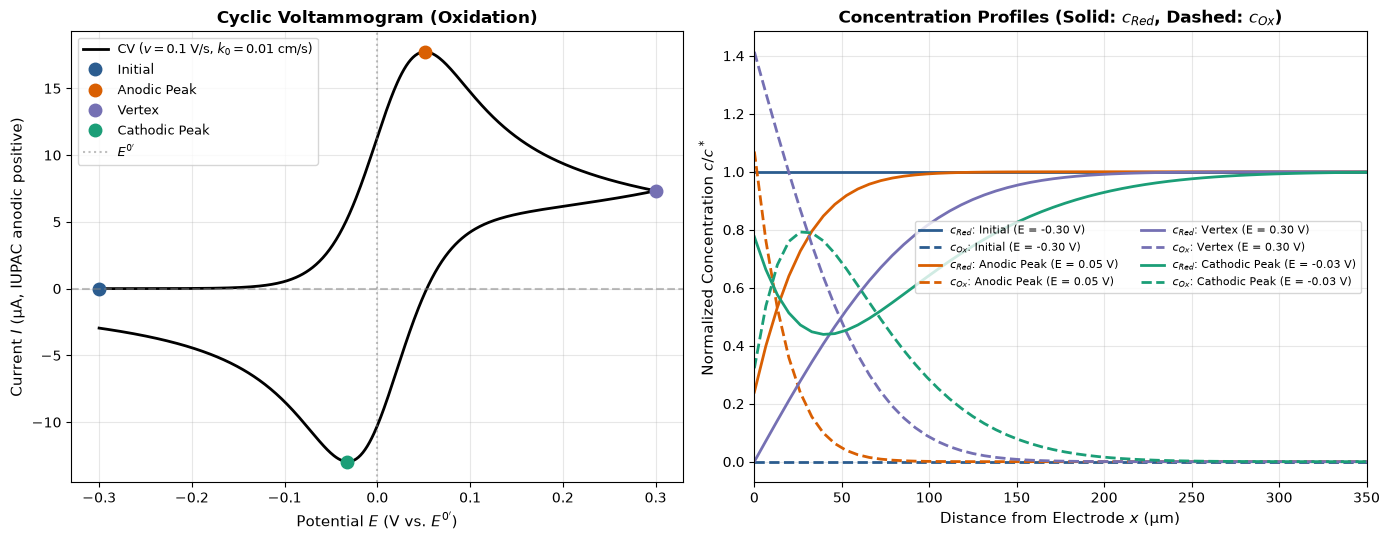

Anodic peak (Oxidation):   I_pa = +17.74 µA at positive potential E_pa = +51.6 mV
Cathodic peak (Reduction): I_pc = -12.96 µA at negative potential E_pc = -32.4 mV
Peak-to-peak separation:   Delta E_p = 84.0 mV (Nernstian ideal = 59.2 mV)
Peak current ratio |I_pc / I_pa| = 0.731 (Theoretical sqrt(D_Ox/D_Red) = 0.707)


In [3]:
# Run baseline simulation
base_sim = simulate_cv_bv(v=0.1, k0=1e-2, D_Red=D_Red, D_Ox=D_Ox)

t_b = base_sim["t"]
E_b = base_sim["E"]
I_b = base_sim["I"]
x_b = base_sim["x"] * 1e4  # Convert to micrometers
t_sw = base_sim["t_switch"]

# Locate anodic (forward) and cathodic (reverse) peak indices
fwd = t_b <= t_sw
rev = t_b > t_sw
idx_pa = np.argmax(I_b[fwd])
idx_pc = np.where(rev)[0][np.argmin(I_b[rev])]
idx_sw = np.argmax(E_b)

key_indices = [0, idx_pa, idx_sw, idx_pc]
labels = [
    f"Initial (E = {E_b[0]:.2f} V)",
    f"Anodic Peak (E = {E_b[idx_pa]:.2f} V)",
    f"Vertex (E = {E_b[idx_sw]:.2f} V)",
    f"Cathodic Peak (E = {E_b[idx_pc]:.2f} V)",
]
colors = ["#2b5c8f", "#d95f02", "#7570b3", "#1b9e77"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: Voltammogram with key state markers
ax1.plot(E_b, I_b, "k-", lw=2, label="CV ($v=0.1$ V/s, $k_0=0.01$ cm/s)")
for idx, lbl, clr in zip(key_indices, labels, colors):
    ax1.plot(
        E_b[idx], I_b[idx], "o", color=clr, markersize=9, label=f"{lbl.split(' (')[0]}"
    )
ax1.axhline(0, color="gray", ls="--", alpha=0.5)
ax1.axvline(E0, color="gray", ls=":", alpha=0.5, label="$E^{0'}$")
ax1.set_xlabel("Potential $E$ (V vs. $E^{0'}$)", fontsize=11)
ax1.set_ylabel("Current $I$ (µA, IUPAC anodic positive)", fontsize=11)
ax1.set_title("Cyclic Voltammogram (Oxidation)", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left", fontsize=9)

# Plot 2: Concentration Profiles
for idx, lbl, clr in zip(key_indices, labels, colors):
    c_R_prof = base_sim["sol"].y[: len(x_b), idx] / c_bulk  # Normalized c / c_bulk
    c_O_prof = base_sim["sol"].y[len(x_b) :, idx] / c_bulk
    ax2.plot(x_b, c_R_prof, color=clr, lw=2, label=f"$c_{{Red}}$: {lbl}")
    ax2.plot(x_b, c_O_prof, color=clr, lw=2, ls="--", label=f"$c_{{Ox}}$: {lbl}")

ax2.set_xlim(0, 350)  # Focus on the diffusion layer (< 350 µm)
ax2.set_xlabel("Distance from Electrode $x$ (µm)", fontsize=11)
ax2.set_ylabel("Normalized Concentration $c / c^*$", fontsize=11)
ax2.set_title(
    "Concentration Profiles (Solid: $c_{Red}$, Dashed: $c_{Ox}$)",
    fontsize=12,
    fontweight="bold",
)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="center right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Print quantitative metrics
I_pa = I_b[idx_pa]
I_pc = I_b[idx_pc]
dEp = (E_b[idx_pa] - E_b[idx_pc]) * 1e3
print(
    f"Anodic peak (Oxidation):   I_pa = {I_pa:+.2f} µA at positive potential E_pa = {E_b[idx_pa] * 1e3:+.1f} mV"
)
print(
    f"Cathodic peak (Reduction): I_pc = {I_pc:+.2f} µA at negative potential E_pc = {E_b[idx_pc] * 1e3:+.1f} mV"
)
print(
    f"Peak-to-peak separation:   Delta E_p = {dEp:.1f} mV (Nernstian ideal = 59.2 mV)"
)
print(
    f"Peak current ratio |I_pc / I_pa| = {abs(I_pc / I_pa):.3f} (Theoretical sqrt(D_Ox/D_Red) = {np.sqrt(D_Ox / D_Red):.3f})"
)

## 4. Effect of Scan Rate ($v$)

The voltammetric response depends on the competition between two timescales:
- **Experimental observation timescale**: $\tau_{\text{exp}} = \frac{\Delta E}{v}$
- **Heterogeneous kinetic timescale**: $\tau_{\text{kin}} \sim \frac{D}{k_0^2}$

At low scan rates, $\tau_{\text{exp}} \gg \tau_{\text{kin}}$; the system has ample time to equilibrate at the electrode surface and behaves reversibly ($\Delta E_p \to 59\text{ mV}$). As scan rate increases, $\tau_{\text{exp}}$ becomes shorter than the kinetic relaxation time, forcing the system into the **quasi-reversible** and eventually **irreversible** regime, accompanied by:
1. Significant peak-to-peak broadening: the anodic peak shifts more positive ($E_{pa} \uparrow$) and the cathodic peak shifts more negative ($E_{pc} \downarrow$), expanding $\Delta E_p$.
2. Peak current scaling that deviates from the ideal reversible Randles–Ševčík $\sqrt{v}$ proportionality (best observed by plotting $I / \sqrt{v}$).

We now simulate scan rates across more than an order of magnitude: $v \in [0.02, 0.05, 0.1, 0.5]\text{ V/s}$ at fixed $k_0 = 10^{-2}\text{ cm/s}$.

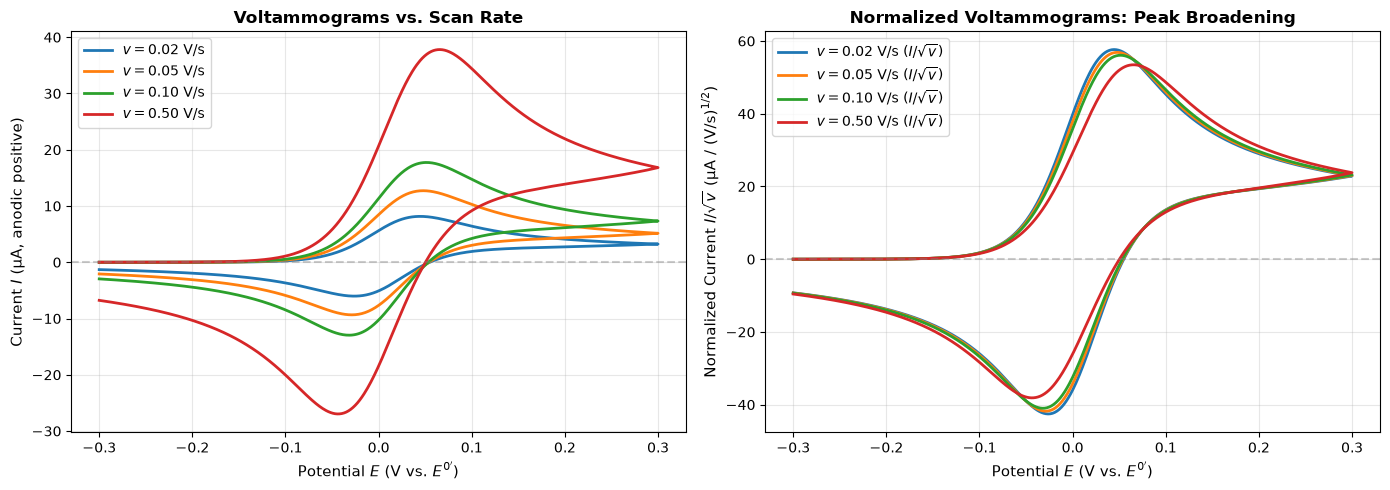

In [4]:
scan_rates = [0.02, 0.05, 0.1, 0.5]
v_sims = {}

for v_val in scan_rates:
    v_sims[v_val] = simulate_cv_bv(v=v_val, k0=1e-2, D_Red=D_Red, D_Ox=D_Ox)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Raw current voltammograms
for v_val in scan_rates:
    sim = v_sims[v_val]
    ax1.plot(sim["E"], sim["I"], lw=2, label=f"$v = {v_val:.2f}$ V/s")
ax1.axhline(0, color="gray", ls="--", alpha=0.4)
ax1.set_xlabel("Potential $E$ (V vs. $E^{0'}$)", fontsize=11)
ax1.set_ylabel("Current $I$ (µA, anodic positive)", fontsize=11)
ax1.set_title("Voltammograms vs. Scan Rate", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

# Panel 2: Normalized current (I / sqrt(v))
for v_val in scan_rates:
    sim = v_sims[v_val]
    I_norm = sim["I"] / np.sqrt(v_val)
    ax2.plot(sim["E"], I_norm, lw=2, label=f"$v = {v_val:.2f}$ V/s ($I / \\sqrt{{v}}$)")
ax2.axhline(0, color="gray", ls="--", alpha=0.4)
ax2.set_xlabel("Potential $E$ (V vs. $E^{0'}$)", fontsize=11)
ax2.set_ylabel("Normalized Current $I / \\sqrt{v}$ (µA / (V/s)$^{1/2}$)", fontsize=11)
ax2.set_title(
    "Normalized Voltammograms: Peak Broadening", fontsize=12, fontweight="bold"
)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 5. Effect of Standard Rate Constant ($k_0$)

Next, we hold the scan rate fixed at $v = 0.1\text{ V/s}$ and vary the standard rate constant $k_0$ across four orders of magnitude:
- $k_0 = 1.0\text{ cm/s}$: **Reversible (Nernstian)** limit. Interfacial reaction is much faster than diffusion. Peaks are sharp and $\Delta E_p \approx 60\text{ mV}$.
- $k_0 = 10^{-2}\text{ cm/s}$: **Quasi-reversible**. Kinetics begin to lag; $\Delta E_p \approx 84\text{ mV}$.
- $k_0 = 10^{-3}\text{ cm/s}$: **Slow Quasi-reversible**. Significant overpotential required to drive electron transfer; $\Delta E_p \approx 210\text{ mV}$.
- $k_0 = 10^{-4}\text{ cm/s}$: **Irreversible**. Electron transfer is so slow that the peaks are flattened, exhibiting wide separation and strong hysteresis.

Thanks to the bounded time step ($\Delta t \le 10\text{ ms}$), the curves resolve smoothly across all kinetic regimes without numerical artifacts.

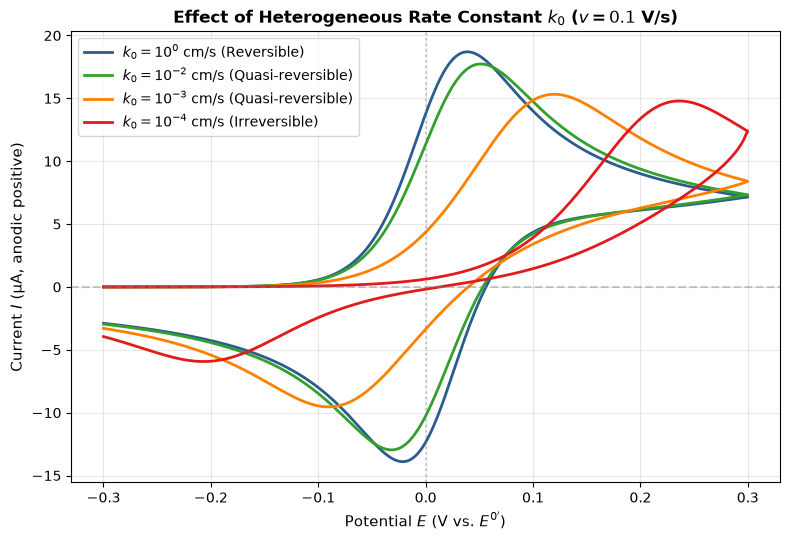

In [5]:
k0_values = [1.0, 1e-2, 1e-3, 1e-4]
k0_sims = {}

for k0_val in k0_values:
    k0_sims[k0_val] = simulate_cv_bv(v=0.1, k0=k0_val, D_Red=D_Red, D_Ox=D_Ox)

plt.figure(figsize=(8, 5.5))
colors_k0 = ["#2b5c8f", "#33a02c", "#ff7f00", "#e31a1c"]

for k0_val, clr in zip(k0_values, colors_k0):
    sim = k0_sims[k0_val]
    # Label with standard rate constant and qualitative regime
    if k0_val >= 0.1:
        regime_lbl = "Reversible"
    elif k0_val >= 1e-3:
        regime_lbl = "Quasi-reversible"
    else:
        regime_lbl = "Irreversible"
    plt.plot(
        sim["E"],
        sim["I"],
        lw=2,
        color=clr,
        label=f"$k_0 = 10^{{{int(np.log10(k0_val))}}}$ cm/s ({regime_lbl})",
    )

plt.axhline(0, color="gray", ls="--", alpha=0.4)
plt.axvline(E0, color="gray", ls=":", alpha=0.4)
plt.xlabel("Potential $E$ (V vs. $E^{0'}$)", fontsize=11)
plt.ylabel("Current $I$ (µA, anodic positive)", fontsize=11)
plt.title(
    "Effect of Heterogeneous Rate Constant $k_0$ ($v = 0.1$ V/s)",
    fontsize=12,
    fontweight="bold",
)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

## 6. The Nicholson Method & Kinetic Regimes

In 1965, R. S. Nicholson published the foundational method for evaluating electron transfer kinetics from cyclic voltammetry. He established that the peak-to-peak potential separation $\Delta E_p = E_{pa} - E_{pc}$ is a unique function of a dimensionless kinetic parameter $\psi$.

For an oxidation reaction with unequal diffusion coefficients ($D_{\text{Red}} \neq D_{\text{Ox}}$), the generalized Nicholson parameter includes the asymmetry factor $\gamma = \sqrt{D_{\text{Red}}/D_{\text{Ox}}}$:
$$\psi = \frac{k_0 \gamma^{1 - \alpha}}{\sqrt{\pi D_{\text{Red}} \frac{F v}{RT}}} = \frac{k_0 \left(\frac{D_{\text{Red}}}{D_{\text{Ox}}}\right)^{(1 - \alpha)/2}}{\sqrt{\pi D_{\text{Red}} \frac{F v}{RT}}}$$
For symmetric electron transfer ($\alpha = 0.5$), $(1 - \alpha)/2 = 0.25$.

### Kinetic Regime Criteria (Matsuda–Ayabe & Nicholson)
| Regime | Condition | $\Delta E_p$ (at 298 K) | Physical Meaning |
|---|---|---|---|
| **Reversible** | $\psi \ge 7$ | $\approx 59\text{ mV}$ | Rapid kinetics; governed purely by mass transport. |
| **Quasi-reversible** | $0.001 < \psi < 7$ | $60\text{ mV} < \Delta E_p < 200\text{ mV}$ | Mixed kinetic and diffusion control. |
| **Irreversible** | $\psi \le 0.001$ | $\Delta E_p > 200\text{ mV}$ | Slow kinetics dominate; severe overpotential. |

### Nicholson's Working Curve
Nicholson tabulated the empirical relationship between $\psi$ and $\Delta E_p$ (Table 1, *Anal. Chem.* 1965). We can interpolate these benchmark values and overlay our simulated oxidation cases directly onto Nicholson's theoretical curve.

Case                   | k0 (cm/s)  | v (V/s)  | psi      | Regime           | E_pa (mV)  | E_pc (mV)  | Sim dEp (mV) | Nicholson (mV)
----------------------------------------------------------------------------------------------------------------------------------
$k_0=1.0, v=0.1$       | 1.0000     | 0.10     | 107.544  | Reversible       | +38.4      | -21.6      | 60.0         | 59.2          
$k_0=0.01, v=0.02$     | 0.0100     | 0.02     | 2.405    | Quasi-reversible | +44.4      | -26.4      | 70.8         | 70.2          
$k_0=0.01, v=0.05$     | 0.0100     | 0.05     | 1.521    | Quasi-reversible | +48.0      | -28.8      | 76.8         | 76.7          
$k_0=0.01, v=0.1$      | 0.0100     | 0.10     | 1.075    | Quasi-reversible | +51.6      | -32.4      | 84.0         | 82.7          
$k_0=0.01, v=0.5$      | 0.0100     | 0.50     | 0.481    | Quasi-reversible | +64.8      | -43.2      | 108.0        | 106.7         
$k_0=0.001, v=0.1$     | 0.0010     | 0.10     | 0.108    |

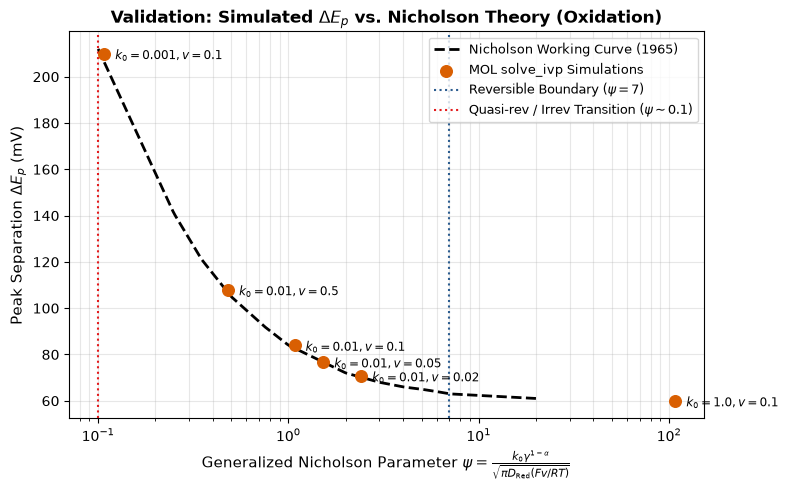

In [6]:
# 1. Nicholson (1965) tabulated working curve values (at 25 °C, n=1, alpha=0.5)
psi_tab = np.array(
    [20.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.75, 0.5, 0.35, 0.25, 0.1]
)
dEp_tab = np.array(
    [61.0, 63.0, 64.0, 65.0, 66.0, 68.0, 72.0, 84.0, 92.0, 105.0, 121.0, 141.0, 212.0]
)


def extract_peaks(sim: dict) -> tuple[float, float, float]:
    # Extract anodic peak (positive E), cathodic peak (negative E), and Delta Ep (in mV)
    t = sim["t"]
    E = sim["E"]
    I = sim["I"]
    t_sw = sim["t_switch"]

    fwd = t <= t_sw
    rev = t > t_sw
    E_fwd, I_fwd = E[fwd], I[fwd]
    E_rev, I_rev = E[rev], I[rev]

    E_pa = E_fwd[np.argmax(I_fwd)]
    E_pc = E_rev[np.argmin(I_rev)]
    dEp = (E_pa - E_pc) * 1e3
    return E_pa, E_pc, dEp


def compute_psi(
    k0: float, v: float, D_Red: float = 1e-5, D_Ox: float = 5e-6, alpha: float = 0.5
) -> float:
    # Compute the generalized Nicholson parameter psi for oxidation with unequal diffusion coefficients
    gamma = np.sqrt(D_Red / D_Ox)
    a = f * v
    return k0 * (gamma ** (1.0 - alpha)) / np.sqrt(np.pi * D_Red * a)


# 2. Extract metrics for simulated cases across regimes
test_cases = [
    {"name": "$k_0=1.0, v=0.1$", "sim": k0_sims[1.0]},
    {"name": "$k_0=0.01, v=0.02$", "sim": v_sims[0.02]},
    {"name": "$k_0=0.01, v=0.05$", "sim": v_sims[0.05]},
    {"name": "$k_0=0.01, v=0.1$", "sim": k0_sims[1e-2]},
    {"name": "$k_0=0.01, v=0.5$", "sim": v_sims[0.5]},
    {"name": "$k_0=0.001, v=0.1$", "sim": k0_sims[1e-3]},
]

results = []
for tc in test_cases:
    s = tc["sim"]
    E_pa, E_pc, dEp_sim = extract_peaks(s)
    psi_val = compute_psi(s["k0"], s["v"], s["D_Red"], s["D_Ox"])

    # Interpolate expected Nicholson dEp if within tabulated range
    if psi_val >= 20.0:
        dEp_nich = 59.2
    elif psi_val >= 0.1:
        dEp_nich = float(
            np.interp(np.log10(psi_val), np.log10(psi_tab)[::-1], dEp_tab[::-1])
        )
    else:
        dEp_nich = np.nan

    if psi_val >= 7.0:
        regime = "Reversible"
    elif psi_val > 0.001:
        regime = "Quasi-reversible"
    else:
        regime = "Irreversible"

    results.append(
        {
            "name": tc["name"],
            "k0": s["k0"],
            "v": s["v"],
            "psi": psi_val,
            "regime": regime,
            "E_pa": E_pa * 1e3,
            "E_pc": E_pc * 1e3,
            "dEp_sim": dEp_sim,
            "dEp_nich": dEp_nich,
        }
    )

# Print comparison table
print(
    f"{'Case':<22} | {'k0 (cm/s)':<10} | {'v (V/s)':<8} | {'psi':<8} | {'Regime':<16} | {'E_pa (mV)':<10} | {'E_pc (mV)':<10} | {'Sim dEp (mV)':<12} | {'Nicholson (mV)':<14}"
)
print("-" * 130)
for r in results:
    nich_str = f"{r['dEp_nich']:.1f}" if not np.isnan(r["dEp_nich"]) else "> 220"
    print(
        f"{r['name']:<22} | {r['k0']:<10.4f} | {r['v']:<8.2f} | {r['psi']:<8.3f} | {r['regime']:<16} | {r['E_pa']:<+10.1f} | {r['E_pc']:<+10.1f} | {r['dEp_sim']:<12.1f} | {nich_str:<14}"
    )

# 3. Plot simulated points against Nicholson Working Curve
psi_fine = np.logspace(-1, 1.3, 200)
dEp_fine = np.interp(np.log10(psi_fine), np.log10(psi_tab)[::-1], dEp_tab[::-1])

plt.figure(figsize=(8, 5))
plt.plot(psi_fine, dEp_fine, "k--", lw=2, label="Nicholson Working Curve (1965)")

# Overlay simulated quasi-reversible cases
psi_pts = [r["psi"] for r in results if not np.isnan(r["dEp_nich"])]
dEp_pts = [r["dEp_sim"] for r in results if not np.isnan(r["dEp_nich"])]
labels_pts = [r["name"] for r in results if not np.isnan(r["dEp_nich"])]

plt.scatter(
    psi_pts, dEp_pts, color="#d95f02", s=70, zorder=5, label="MOL solve_ivp Simulations"
)
for p, dep, lbl in zip(psi_pts, dEp_pts, labels_pts):
    plt.annotate(
        lbl, (p, dep), textcoords="offset points", xytext=(8, -4), fontsize=8.5
    )

# Highlight regime thresholds
plt.axvline(7.0, color="#2b5c8f", ls=":", label=r"Reversible Boundary ($\psi = 7$)")
plt.axvline(
    0.1,
    color="#e31a1c",
    ls=":",
    label=r"Quasi-rev / Irrev Transition ($\psi \sim 0.1$)",
)

plt.xscale("log")
plt.xlabel(
    r"Generalized Nicholson Parameter $\psi = \frac{k_0 \gamma^{1-\alpha}}{\sqrt{\pi D_{\mathrm{Red}} (F v / RT)}}$",
    fontsize=11,
)
plt.ylabel(r"Peak Separation $\Delta E_p$ (mV)", fontsize=11)
plt.title(
    r"Validation: Simulated $\Delta E_p$ vs. Nicholson Theory (Oxidation)",
    fontsize=12,
    fontweight="bold",
)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Summary & Key Takeaways

In this tutorial, we demonstrated how to simulate cyclic voltammetry for an oxidation reaction with non-linear Butler–Volmer kinetics and unequal diffusion coefficients using `solve_ivp`:

1. **Oxidation Reaction & IUPAC Conventions**: Sweeping from negative potentials ($E_{\text{start}} = -0.3\text{ V}$) to positive potentials ($E_{\text{vertex}} = +0.3\text{ V}$) produces an **anodic oxidation peak** at **positive potentials** ($E_{pa} > 0$) with positive current ($I > 0$), and a **cathodic reduction peak** on the reverse sweep at **negative potentials** ($E_{pc} < 0$) with negative current ($I < 0$).
2. **Method of Lines with Ghost Nodes & Bounded Step Size**: Formulating the Butler–Volmer surface boundary condition via a second-order ghost-node stencil converts complex Robin boundary fluxes into standard ODEs. Limiting the solver time step via `max_step` ensures that both the potential turnaround at $t_{\text{switch}}$ and the kinetic peaks are smoothly resolved without numerical ringing.
3. **Impact of Unequal Diffusion ($D_{\text{Red}} \neq D_{\text{Ox}}$)**: Asymmetry in diffusion coefficients directly alters the concentration profiles and breaks the peak current symmetry ($|I_{pc}/I_{pa}| \approx \sqrt{D_{\text{Ox}}/D_{\text{Red}}} \neq 1.0$).
4. **Kinetic Broadening**: Increasing scan rate $v$ or decreasing standard rate constant $k_0$ reduces the time available for interfacial electron transfer, expanding peak-to-peak separation $\Delta E_p$.
5. **Nicholson Benchmark**: By calculating the generalized Nicholson parameter $\psi$, we demonstrated excellent agreement between numerical simulations and Nicholson's working curve, providing a rigorous quantitative framework to distinguish **reversible**, **quasi-reversible**, and **irreversible** regimes.